# Conceptual

## Q1.
```{admonition}
:class: note
Using basic statistical properties of the variance, as well as single-variable calculus, prove that
$$
\alpha = \frac{\sigma_{Y}^{2}-\sigma_{XY}}{\sigma_{X}^{2}+\sigma_{Y}^{2}-2\sigma_{XY}}
$$
minimizes $\operatorname{Var}(\alpha X + (1 -\alpha)Y )$.

We have
\begin{align*}
\operatorname{Var}(\alpha X + (1 -\alpha)Y )
&= \alpha^{2}\operatorname{Var}(X) + (1 -\alpha)^{2}\operatorname{Var}(Y)+2(1 -\alpha)\alpha\operatorname{Cov}(X,Y)\\
&=\alpha^{2}\sigma_{X}^{2} + (1 -\alpha)^{2}\sigma_{Y}^{2}+2(1 -\alpha)\alpha\sigma_{XY}.
\end{align*}

Taking the derivative with respect to $\alpha$ we get
$$
\frac{\operatorname{d}}{\operatorname{d}{\alpha}} (\alpha^{2}\sigma_{X}^{2} + (1 -\alpha)^{2}\sigma_{Y}^{2}+2(1 -\alpha)\alpha\sigma_{XY})
= 2\alpha\sigma_{X}^{2}-2(1-\alpha)\sigma_{Y}^{2}+2((1 -\alpha)\sigma_{XY}-\alpha\sigma_{XY}).
$$

Equating to zero gives
\begin{align*}
0 &= 2\alpha\sigma_{X}^{2}-2(1-\alpha)\sigma_{Y}^{2}+2((1 -\alpha)\sigma_{XY}-\alpha\sigma_{XY})\\
  &= \alpha\sigma_{X}^{2}-\sigma_{Y}^{2}+\alpha\sigma_{Y}^{2}+\sigma_{XY} -2\alpha\sigma_{XY}\\
  &= \alpha(\sigma_{X}^{2}+\sigma_{Y}^{2}-2\sigma_{XY})+\sigma_{XY}-\sigma_{Y}^{2}
\end{align*}
which, after some rearrangement, gives
$$
\alpha = \frac{\sigma_{Y}^{2}-\sigma_{XY}}{\sigma_{X}^{2}+\sigma_{Y}^{2}-2\sigma_{XY}}.
$$

As seen at the start, the variance we are finding is a quadratic function in $\alpha$ with $\alpha^{2}$ coefficient equal to $\sigma_{X}^{2}+\sigma_{Y}^{2}-2\sigma_{XY} = \operatorname{Var}(X-Y) \geq 0$. If $\operatorname{Var}(X-Y)\neq 0$, we find that this is a minimum.

Note that if $\operatorname{Var}(X-Y) = 0$, then $X-Y = c$ for some constant $c$ almost surely. In this case we would be trying to minimize
$$
\operatorname{Var}(\alpha X + (1-\alpha)(X+c)) = \operatorname{Var}(\alpha X + X-\alpha X + c -c\alpha) = \operatorname{Var}(X),
$$ using the fact variance is shift invariant. That is, in this case there is no $\alpha$ to minimize.

## Q2.
```{admonition}
:class: note
We will now derive the probability that a given observation is part of a bootstrap sample. Suppose that we obtain a bootstrap sample from a set of $n$ observations.

```{admonition}
:class: note
(a) What is the probability that the first bootstrap observation is not the $j$th observation from the original sample?

There is a $1/n$ chance for the first observation to be the $j$th observation. Therefore, the probability of not being the $j$th observation is $1-1/n$.

```{admonition}
:class: note
(b) What is the probability that the second bootstrap observation is *not* the $j$th observation from the original sample?

We are sampling with replacement, so this is the same situation as (a). That is, the probability is still $1-1/n$.

```{admonition}
:class: note
(c) Argue that the probability that the $j$th observation is not in the bootstrap sample is $(1 − 1/n)^{n}$.

We need the first, second, ..., $n$th bootstrap observation to not be the $j$th observation from the sample. Since we are building the bootstrap with replacement, each probability is $1-1/n$, and since each observation is independent we multiply the probabilities of the $n$ events to get $(1 − 1/n)^{n}$.

```{admonition}
:class: note
(d) When $n = 5$, what is the probability that the $j$th observation is in the bootstrap sample?

In [14]:
n = 5
print(1-(1-1/n)**n)

0.6723199999999999


```{admonition}
:class: note
(e) When $n=100$.

In [3]:
n = 100
print(1-(1-1/n)**n)

0.6339676587267709


```{admonition}
:class: note
(f) When $n=10\, 000$.

In [4]:
n = 10000
print(1-(1-1/n)**n)

0.6321389535670295


```{admonition}
:class: note
(g) Create a plot that displays, for each integer value of $n$ from $1$ to $100\, 000$, the probability that the $j$th observation is in the bootstrap sample.

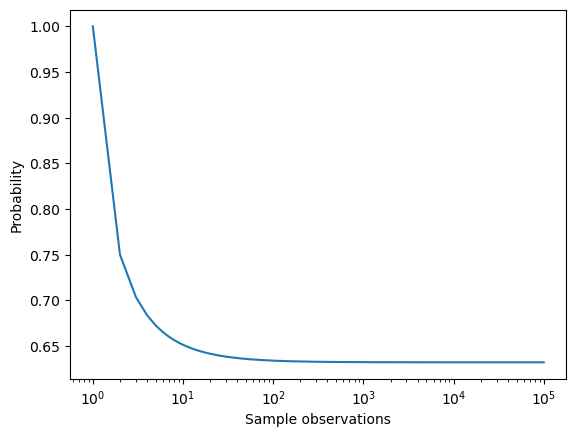

In [9]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1,100001)
y = 1-(1-1/x)**x
plt.plot(x,y)
plt.xlabel('Sample observations')
plt.ylabel('Probability')
plt.xscale('log');

```{admonition}
:class: note
(h) We will now investigate numerically the probability that a bootstrap sample of size $n = 100$ contains the $j$th observation. Here $j = 4$. We first create an array `store` with values that will subsequently be overwritten using the function `np.empty()`. We then repeatedly create bootstrap samples, and each time we record whether or not the fifth observation is contained in the bootstrap sample.

In [13]:
rng = np.random.default_rng(1728)
store = np.empty(10000)
for i in range(10000):
    store[i] = np.sum(rng.choice(100,size=100, replace=True) == 4) > 0
np.mean(store)

np.float64(0.6442)

## Q3.
```{admonition}
:class: note
We now review $k$-fold cross-validation.

```{admonition}
:class: note
(a) Explain how $k$-fold cross validation is implemented.

The sample is divided into $k$ subsamples with approximately $n/k$ elements each. We then iterate through the $k$ subsamples by choosing one as a test set for calculating our choice of accuracy, say mean squared error for regression, by using the remainder $k-1$ as training. The test error is then estimated as the average of the accuracy of the $k$ model fits.

```{admonition}
:class: note
(b) What are the advantages and disadvantages of k-fold cross-validation relative to

```{admonition}
:class: note
i. The validation set approach?

Validation set requires only training and testing one model. However, the variance of the test error estimate is much higher when using only one validation set. Furthermore, part of the observations go unused in training as they are left out for testing.

```{admonition}
:class: note
ii. LOOCV?

This is $k$-fold cross-validation with $k = n$, so the differences come from using smaller values of $k$. Since we can use smaller $k$, we spend less time training and fitting models. The impact on the variance is harder to predict and can differ depending on the model and data.
See https://stats.stackexchange.com/a/357749.

## Q4.
```{admonition}
:class: note
Suppose that we use some statistical learning method to make a prediction for the response $Y$ for a particular value of the predictor $X$. Carefully describe how we might estimate the standard deviation of our prediction.

Create some large number $B$ of bootstrap samples from the data. On each of these, fit the model and determine the prediction $\hat{y}_{i}$. We can estimate the standard deviation using
$$
\sigma^{2} = \frac{1}{B-1}\sum_{i=1}^{B}\left(\hat{y}_{i} - \overline{\hat{y}_{i}} \right)^{2}.
$$